# Práctica 2 - Generación de Variables Aleatorias Discretas

**CC2017 - Modelación y Simulación**  
Solución reproducible en Python

Este notebook resuelve el caso de inventario y los ejercicios 2 al 9. Cada simulación usa una semilla independiente; cuando existe una respuesta exacta, se emplea como referencia y no como sustituto de la simulación.

In [1]:
"""Solución reproducible de la Práctica 2 de Modelación y Simulación.

Cada ejercicio está implementado como una función independiente. Al ejecutar este
archivo se crean resultados tabulares y figuras en ``resultados/``.
"""

from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Callable, Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


BASE_DIR = Path.cwd()
RESULTS_DIR = BASE_DIR / "resultados"
Z_975 = 1.959963984540054


def intervalo_mc(valores: np.ndarray) -> tuple[float, float, float, float]:
    """Retorna estimación, error estándar y extremos del IC normal de 95%."""
    valores = np.asarray(valores, dtype=float)
    estimacion = float(valores.mean())
    ee = float(valores.std(ddof=1) / math.sqrt(valores.size))
    return estimacion, ee, estimacion - Z_975 * ee, estimacion + Z_975 * ee


# ---------------------------------------------------------------------------
# Ejercicio 1: inventario de botellas
# ---------------------------------------------------------------------------

DEMANDAS = np.arange(6)
PROB_DEMANDA = np.array([0.05, 0.15, 0.30, 0.30, 0.15, 0.05])
CDF_DEMANDA = np.cumsum(PROB_DEMANDA)


def demanda_inversa(u: float) -> int:
    """Transformada inversa para la distribución discreta de demanda."""
    if not 0.0 <= u < 1.0:
        raise ValueError("u debe pertenecer a [0, 1)")
    return int(np.searchsorted(CDF_DEMANDA, u, side="right"))


def simular_inventario(
    dias: int = 15, inventario: int = 3, semilla: int = 20260805
) -> tuple[pd.DataFrame, dict[str, float]]:
    """Simula la tienda y retorna el detalle diario y sus métricas."""
    rng = np.random.default_rng(semilla)
    uniformes = rng.random(dias)
    demanda = np.searchsorted(CDF_DEMANDA, uniformes, side="right")
    ventas = np.minimum(demanda, inventario)
    sobrante = np.maximum(inventario - demanda, 0)
    perdida = np.maximum(demanda - inventario, 0)

    resultado = np.where(
        perdida > 0,
        np.char.add("Faltante de ", perdida.astype(str)),
        np.where(
            sobrante > 0,
            np.char.add("Sobrante de ", sobrante.astype(str)),
            "Inventario exacto",
        ),
    )
    detalle = pd.DataFrame(
        {
            "día": np.arange(1, dias + 1),
            "número_aleatorio": uniformes,
            "demanda": demanda,
            "inventario": inventario,
            "ventas": ventas,
            "sobrante": sobrante,
            "ventas_perdidas": perdida,
            "resultado": resultado,
        }
    )
    demanda_total = int(demanda.sum())
    metricas = {
        "días": dias,
        "inventario_diario": inventario,
        "demanda_total": demanda_total,
        "ventas_totales": int(ventas.sum()),
        "ventas_perdidas": int(perdida.sum()),
        "sobrante_total": int(sobrante.sum()),
        "días_con_faltante": int((perdida > 0).sum()),
        "días_con_sobrante": int((sobrante > 0).sum()),
        "demanda_media": float(demanda.mean()),
        "tasa_llenado": float(ventas.sum() / demanda_total) if demanda_total else 1.0,
        "utilización_inventario": float(ventas.sum() / (dias * inventario))
        if inventario
        else 0.0,
    }
    return detalle, metricas


def evaluar_politicas_inventario(maximo: int = 5) -> pd.DataFrame:
    """Métricas teóricas exactas para inventarios de 0 a ``maximo``."""
    filas = []
    esperanza_demanda = float(DEMANDAS @ PROB_DEMANDA)
    for s in range(maximo + 1):
        ventas = np.minimum(DEMANDAS, s)
        faltante = np.maximum(DEMANDAS - s, 0)
        sobrante = np.maximum(s - DEMANDAS, 0)
        e_ventas = float(ventas @ PROB_DEMANDA)
        filas.append(
            {
                "inventario": s,
                "E_ventas": e_ventas,
                "E_faltante": float(faltante @ PROB_DEMANDA),
                "E_sobrante": float(sobrante @ PROB_DEMANDA),
                "P_faltante": float(PROB_DEMANDA[DEMANDAS > s].sum()),
                "tasa_llenado": e_ventas / esperanza_demanda,
            }
        )
    return pd.DataFrame(filas)


# ---------------------------------------------------------------------------
# Ejercicio 2: variable discreta arbitraria
# ---------------------------------------------------------------------------

def generar_x_ejercicio_2(u: float) -> int:
    """Árbol balanceado: genera X con exactamente dos comparaciones."""
    if not 0.0 <= u < 1.0:
        raise ValueError("u debe pertenecer a [0, 1)")
    if u < 0.50:
        return 1 if u < 0.30 else 2
    return 3 if u < 0.85 else 4


# ---------------------------------------------------------------------------
# Ejercicio 3: puntos fijos en una permutación
# ---------------------------------------------------------------------------

def simular_puntos_fijos(
    repeticiones: int = 100_000, n: int = 100, semilla: int = 20260305
) -> tuple[dict[str, float], np.ndarray]:
    rng = np.random.default_rng(semilla)
    referencia = np.arange(n)
    aciertos = np.empty(repeticiones, dtype=np.int16)
    for i in range(repeticiones):
        aciertos[i] = np.count_nonzero(rng.permutation(n) == referencia)
    media, ee, li, ls = intervalo_mc(aciertos)
    resumen = {
        "repeticiones": repeticiones,
        "media_simulada": media,
        "error_estándar_media": ee,
        "IC95_media_inferior": li,
        "IC95_media_superior": ls,
        "varianza_simulada": float(aciertos.var(ddof=1)),
        "media_exacta": 1.0,
        "varianza_exacta": 1.0,
    }
    return resumen, aciertos


# ---------------------------------------------------------------------------
# Ejercicio 4: Bernoulli mediante saltos geométricos
# ---------------------------------------------------------------------------

def bernoulli_por_saltos(
    n: int = 25,
    p: float = 0.8,
    semilla: int = 20260402,
    uniformes: Iterable[float] | None = None,
) -> tuple[np.ndarray, int, list[float]]:
    """Genera Bernoulli(p) ubicando el resultado menos probable por saltos.

    Para p > 1/2 se generan las posiciones de los ceros. Cada uniforme produce
    un salto geométrico y el último confirma que no queda otro cero en el tramo.
    """
    if not 0.5 < p < 1.0:
        raise ValueError("Esta versión eficiente supone 1/2 < p < 1")
    q = 1.0 - p
    rng = np.random.default_rng(semilla)
    fuente = iter(uniformes) if uniformes is not None else None
    secuencia = np.ones(n, dtype=np.int8)
    usados: list[float] = []
    posicion = 0
    while posicion < n:
        u = float(next(fuente) if fuente is not None else rng.random())
        if not 0.0 < u < 1.0:
            raise ValueError("Los uniformes para el método geométrico deben estar en (0, 1)")
        usados.append(u)
        salto = math.floor(math.log(u) / math.log(1.0 - q)) + 1
        posicion += salto
        if posicion <= n:
            secuencia[posicion - 1] = 0
    return secuencia, len(usados), usados


# ---------------------------------------------------------------------------
# Ejercicio 5: completar las sumas de dos dados
# ---------------------------------------------------------------------------

PROB_SUMAS_DADOS = np.array([1, 2, 3, 4, 5, 6, 5, 4, 3, 2, 1], dtype=float) / 36.0


def esperanza_exacta_coleccion_dados() -> float:
    """Resuelve E[tiempo restante] en los 2^11 estados de colección."""
    m = len(PROB_SUMAS_DADOS)
    completo = (1 << m) - 1
    e = np.zeros(completo + 1)
    for mascara in range(completo - 1, -1, -1):
        faltantes = [j for j in range(m) if not mascara & (1 << j)]
        p_nuevo = float(PROB_SUMAS_DADOS[faltantes].sum())
        futuro = sum(
            PROB_SUMAS_DADOS[j] * e[mascara | (1 << j)] for j in faltantes
        )
        e[mascara] = (1.0 + futuro) / p_nuevo
    return float(e[0])


def simular_coleccion_dados(
    repeticiones: int = 200_000, semilla: int = 20260505
) -> tuple[dict[str, float], np.ndarray]:
    """Simulación vectorizada hasta observar las once sumas posibles."""
    rng = np.random.default_rng(semilla)
    completo = (1 << 11) - 1
    vistos = np.zeros(repeticiones, dtype=np.uint16)
    lanzamientos = np.zeros(repeticiones, dtype=np.int32)
    activos = np.arange(repeticiones)
    while activos.size:
        sumas = rng.integers(1, 7, size=(activos.size, 2)).sum(axis=1)
        vistos[activos] |= (1 << (sumas - 2)).astype(np.uint16)
        lanzamientos[activos] += 1
        activos = activos[vistos[activos] != completo]
    media, ee, li, ls = intervalo_mc(lanzamientos)
    resumen = {
        "repeticiones": repeticiones,
        "media_simulada": media,
        "error_estándar": ee,
        "IC95_inferior": li,
        "IC95_superior": ls,
        "media_exacta": esperanza_exacta_coleccion_dados(),
        "desviación_estándar_simulada": float(lanzamientos.std(ddof=1)),
    }
    return resumen, lanzamientos


# ---------------------------------------------------------------------------
# Ejercicio 6: suma de valores distintos
# ---------------------------------------------------------------------------

def estimar_suma_distintos(
    elementos: np.ndarray,
    valor: Callable[[object], float],
    muestras: int = 20_000,
    semilla: int = 20260606,
) -> tuple[float, float]:
    """Estimador Hansen-Hurwitz de la suma sobre elementos distintos.

    Si el elemento a aparece m_a veces en una lista de longitud n, una posición
    uniforme lo selecciona con probabilidad m_a/n. Por ello n*v(a)/m_a es
    insesgado para la suma de los valores de los tipos distintos.
    """
    elementos = np.asarray(elementos)
    n = elementos.size
    unicos, conteos = np.unique(elementos, return_counts=True)
    multiplicidad = dict(zip(unicos.tolist(), conteos.tolist()))
    rng = np.random.default_rng(semilla)
    muestra = elementos[rng.integers(0, n, size=muestras)]
    aportes = np.array([n * valor(a) / multiplicidad[a] for a in muestra], dtype=float)
    estimacion, ee, _, _ = intervalo_mc(aportes)
    return estimacion, ee


# ---------------------------------------------------------------------------
# Ejercicios 7 y 8: las demostraciones se presentan en el notebook/README.
# ---------------------------------------------------------------------------


# ---------------------------------------------------------------------------
# Ejercicio 9: integración Monte Carlo
# ---------------------------------------------------------------------------

EULER_GAMMA = 0.5772156649015328606


def ei_positivo(x: float, tolerancia: float = 1e-16) -> float:
    """Ei(x) para x > 0 mediante su serie convergente."""
    if x <= 0:
        raise ValueError("x debe ser positivo")
    termino = x
    suma = termino
    k = 1
    while abs(termino / k) > tolerancia:
        k += 1
        termino *= x / k
        suma += termino / k
    return EULER_GAMMA + math.log(x) + suma


def erfi(x: float, tolerancia: float = 1e-16) -> float:
    """Función error imaginaria real mediante serie de potencias."""
    termino = x
    suma = termino
    k = 0
    while abs(termino / (2 * k + 1)) > tolerancia:
        k += 1
        termino *= x * x / k
        suma += termino / (2 * k + 1)
    return 2.0 * suma / math.sqrt(math.pi)


def integrar_monte_carlo(
    muestras: int = 500_000, semilla: int = 20260909
) -> pd.DataFrame:
    rng = np.random.default_rng(semilla)
    resultados: list[dict[str, float | str]] = []

    def agregar(nombre: str, valores: np.ndarray, exacto: float) -> None:
        est, ee, li, ls = intervalo_mc(valores)
        resultados.append(
            {
                "integral": nombre,
                "estimación_MC": est,
                "error_estándar": ee,
                "IC95_inferior": li,
                "IC95_superior": ls,
                "valor_exacto": exacto,
                "error_absoluto": abs(est - exacto),
            }
        )

    u = rng.random(muestras)
    agregar("3", np.exp(np.exp(u)), ei_positivo(math.e) - ei_positivo(1.0))

    u = rng.random(muestras)
    agregar("4", np.power(1.0 - u * u, 1.5), 3.0 * math.pi / 16.0)

    x = rng.uniform(-2.0, 2.0, muestras)
    exacta_5 = (
        math.exp(-0.25)
        * math.sqrt(math.pi)
        / 2.0
        * (erfi(2.5) + erfi(1.5))
    )
    agregar("5", 4.0 * np.exp(x + x * x), exacta_5)

    u = rng.random(muestras)
    denominador = ((1.0 - u) ** 2 + u**2) ** 2
    agregar("6", u * (1.0 - u) / denominador, 0.5)

    u = rng.random(muestras)
    z = np.tan(math.pi * (u - 0.5))
    agregar("7", math.pi * (1.0 + z * z) * np.exp(-(z * z)), math.sqrt(math.pi))

    x = rng.random(muestras)
    y = rng.random(muestras)
    exacta_8 = (
        math.sqrt(math.pi) * (erfi(2.0) - erfi(1.0))
        + (2.0 * math.e - 1.0 - math.exp(4.0)) / 2.0
    )
    agregar("8", np.exp((x + y) ** 2), exacta_8)

    x = rng.exponential(1.0, muestras)
    y = rng.exponential(1.0, muestras)
    agregar("9", (y < x).astype(float), 0.5)

    return pd.DataFrame(resultados)


def crear_figuras(
    puntos_fijos: np.ndarray,
    lanzamientos: np.ndarray,
    politicas: pd.DataFrame,
) -> None:
    plt.style.use("seaborn-v0_8-whitegrid")

    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    valores, frecuencias = np.unique(puntos_fijos, return_counts=True)
    ax.bar(valores, frecuencias / puntos_fijos.size, color="#2463A9")
    ax.set(xlabel="Número de aciertos", ylabel="Frecuencia relativa", title="Puntos fijos en 100 cartas")
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / "ejercicio_3_puntos_fijos.png", dpi=180)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    ax.hist(lanzamientos, bins=60, color="#2C8C6B", edgecolor="white")
    ax.axvline(lanzamientos.mean(), color="#9C2E35", linestyle="--", label="Media simulada")
    ax.set(xlabel="Lanzamientos necesarios", ylabel="Frecuencia", title="Tiempo para observar las 11 sumas")
    ax.legend()
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / "ejercicio_5_dados.png", dpi=180)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    ax.plot(politicas["inventario"], politicas["E_faltante"], marker="o", label="Faltante esperado")
    ax.plot(politicas["inventario"], politicas["E_sobrante"], marker="o", label="Sobrante esperado")
    ax.axvline(3, color="#555555", linestyle="--", label="Política actual")
    ax.set(xlabel="Inventario inicial", ylabel="Botellas por día", title="Compromiso entre faltante y sobrante")
    ax.legend()
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / "ejercicio_1_politicas.png", dpi=180)
    plt.close(fig)


def ejecutar_todo(verbose: bool = True) -> dict[str, object]:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    detalle, inventario = simular_inventario()
    politicas = evaluar_politicas_inventario()
    puntos, muestra_puntos = simular_puntos_fijos()
    bernoulli, n_uniformes, uniformes = bernoulli_por_saltos()
    dados, muestra_dados = simular_coleccion_dados()
    integrales = integrar_monte_carlo()

    detalle.to_csv(RESULTS_DIR / "ejercicio_1_dias.csv", index=False)
    politicas.to_csv(RESULTS_DIR / "ejercicio_1_politicas.csv", index=False)
    integrales.to_csv(RESULTS_DIR / "ejercicio_9_integrales.csv", index=False)
    crear_figuras(muestra_puntos, muestra_dados, politicas)

    resumen: dict[str, object] = {
        "ejercicio_1": inventario,
        "ejercicio_3": puntos,
        "ejercicio_4": {
            "secuencia": bernoulli.tolist(),
            "números_aleatorios_usados": n_uniformes,
            "uniformes": uniformes,
            "valor_esperado_de_uniformes": 25 * (1 - 0.8) + 0.8,
        },
        "ejercicio_5": dados,
        "ejercicio_9": integrales.to_dict(orient="records"),
    }
    with (RESULTS_DIR / "resumen.json").open("w", encoding="utf-8") as archivo:
        json.dump(resumen, archivo, ensure_ascii=False, indent=2)

    if verbose:
        print("\nEJERCICIO 1 - DETALLE DE 15 DÍAS")
        print(detalle.to_string(index=False, formatters={"número_aleatorio": "{:.6f}".format}))
        print("\nMétricas de la corrida:")
        print(pd.Series(inventario).to_string())
        print("\nComparación teórica de políticas:")
        print(politicas.round(4).to_string(index=False))

        print("\nEJERCICIO 3 - PUNTOS FIJOS")
        print(pd.Series(puntos).to_string())

        print("\nEJERCICIO 4 - BERNOULLI POR SALTOS")
        print("Secuencia:", "".join(map(str, bernoulli.tolist())))
        print("Uniformes usados:", n_uniformes)
        print("E[N] = 25(0.2) + 0.8 = 5.8")

        print("\nEJERCICIO 5 - DOS DADOS")
        print(pd.Series(dados).to_string())

        print("\nEJERCICIO 9 - INTEGRALES")
        print(integrales.round(8).to_string(index=False))

    return resumen



In [2]:
from IPython.display import display, Image

resumen = ejecutar_todo(verbose=False)
print('Resultados regenerados correctamente en:', RESULTS_DIR)

Resultados regenerados correctamente en: /Users/yhimp/Desktop/UVG/UVG/semestre 6/ModSim/practica-generacion-discretas/resultados


## Ejercicio 1 - Política de inventario

Se aplica la transformada inversa a la CDF de la demanda: los intervalos `[0,.05)`, `[.05,.20)`, `[.20,.50)`, `[.50,.80)`, `[.80,.95)` y `[.95,1)` producen demandas de 0 a 5. Para cada día se calculan `ventas=min(D,3)`, `sobrante=max(3-D,0)` y `faltante=max(D-3,0)`.

In [3]:
detalle, metricas = simular_inventario()
display(detalle.style.format({'número_aleatorio': '{:.6f}'}))
display(pd.Series(metricas, name='valor').to_frame())

,día,número_aleatorio,demanda,inventario,ventas,sobrante,ventas_perdidas,resultado
0,1,0.204993,2,3,2,1,0,Sobrante de 1
1,2,0.719527,3,3,3,0,0,Inventario exacto
2,3,0.741879,3,3,3,0,0,Inventario exacto
3,4,0.909558,4,3,3,0,1,Faltante de 1
4,5,0.534674,3,3,3,0,0,Inventario exacto
5,6,0.743837,3,3,3,0,0,Inventario exacto
6,7,0.131823,1,3,1,2,0,Sobrante de 2
7,8,0.909667,4,3,3,0,1,Faltante de 1
8,9,0.267315,2,3,2,1,0,Sobrante de 1
9,10,0.528616,3,3,3,0,0,Inventario exacto


,valor
días,15.000000
inventario_diario,3.000000
demanda_total,46.000000
ventas_totales,41.000000
ventas_perdidas,5.000000
sobrante_total,4.000000
días_con_faltante,4.000000
días_con_sobrante,3.000000
demanda_media,3.066667
tasa_llenado,0.891304


La corrida de 15 días es una observación reproducible, pero la recomendación debe apoyarse también en las métricas teóricas. Para tres botellas se obtiene:

- demanda esperada: 2.50 botellas/día;
- ventas esperadas: 2.25;
- faltante esperado: 0.25;
- sobrante esperado: 0.75;
- probabilidad de faltante: 0.20;
- tasa de llenado por unidades: 2.25/2.50 = 0.90.

Si `Cu` es el costo de una unidad faltante y `Co` el costo de una unidad sobrante, el criterio newsvendor elige el menor inventario `s` tal que `F(s) >= Cu/(Cu+Co)`. La política de tres es óptima exactamente cuando `Co < Cu <= 4Co`. Sin estos costos no se puede afirmar una política económicamente única; operativamente, tres botellas ofrece 90% de servicio con faltantes en 20% de los días.

,inventario,E_ventas,E_faltante,E_sobrante,P_faltante,tasa_llenado
0,0,0.00,2.50,0.00,95%,0%
1,1,0.95,1.55,0.05,80%,38%
2,2,1.75,0.75,0.25,50%,70%
3,3,2.25,0.25,0.75,20%,90%
4,4,2.45,0.05,1.55,5%,98%
5,5,2.50,0.00,2.50,0%,100%


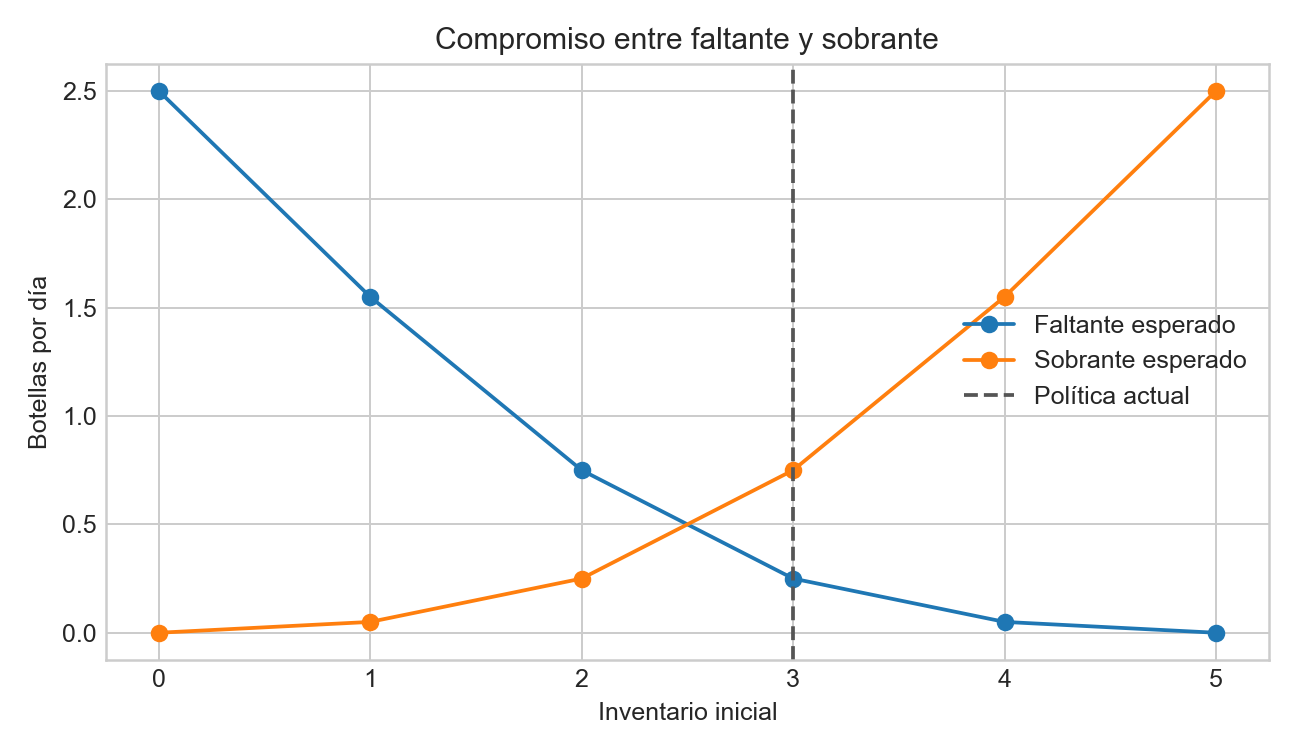

In [4]:
display(evaluar_politicas_inventario().style.format({
    'E_ventas': '{:.2f}', 'E_faltante': '{:.2f}', 'E_sobrante': '{:.2f}',
    'P_faltante': '{:.0%}', 'tasa_llenado': '{:.0%}'
}))
display(Image(filename=str(RESULTS_DIR / 'ejercicio_1_politicas.png'), width=720))

## Ejercicio 2 - Variable discreta con dos comparaciones

Un árbol balanceado usa siempre dos comparaciones:

```text
si U < 0.50:
    X = 1 si U < 0.30; de lo contrario X = 2
de lo contrario:
    X = 3 si U < 0.85; de lo contrario X = 4
```

Los cuatro intervalos tienen longitudes 0.30, 0.20, 0.35 y 0.15, respectivamente.

In [5]:
pd.DataFrame({
    'intervalo de U': ['[0,.30)', '[.30,.50)', '[.50,.85)', '[.85,1)'],
    'X': [generar_x_ejercicio_2(u) for u in (0.1, 0.4, 0.7, 0.9)],
    'probabilidad': [0.30, 0.20, 0.35, 0.15],
})

,intervalo de U,X,probabilidad
0,"[0,.30)",1,0.30
1,"[.30,.50)",2,0.20
2,"[.50,.85)",3,0.35
3,"[.85,1)",4,0.15


## Ejercicio 3 - Aciertos en una baraja

Sea `I_i` el indicador de que la carta `i` aparece en la posición `i`, y `X=sum(I_i)`. Como `P(I_i=1)=1/100`, por linealidad `E[X]=1`. Además, `Var(I_i)=99/10000` y para `i != j`, `Cov(I_i,I_j)=1/(100·99)-1/10000`. Al sumar las 100 varianzas y las 100·99 covarianzas ordenadas se obtiene `Var(X)=1`.

,valor
repeticiones,100000.000000
media_simulada,0.999860
error_estándar_media,0.003166
IC95_media_inferior,0.993655
IC95_media_superior,1.006065
varianza_simulada,1.002350
media_exacta,1.000000
varianza_exacta,1.000000


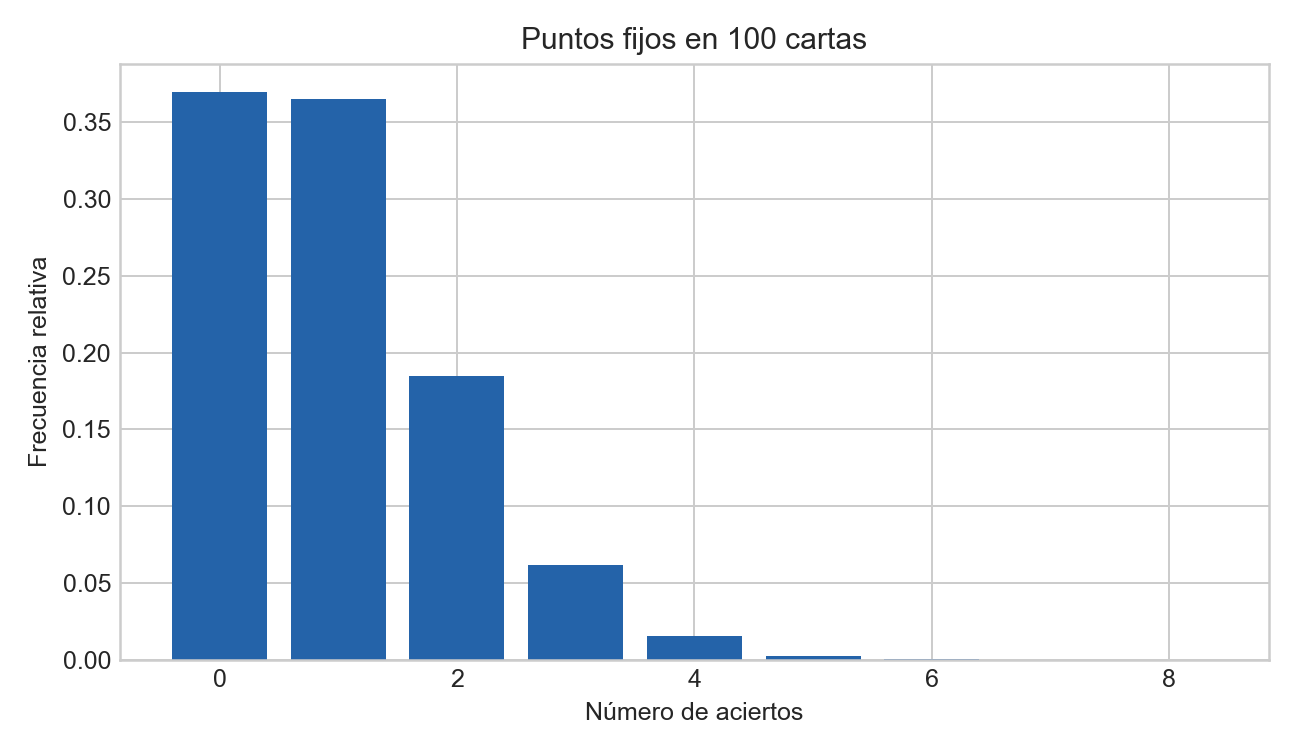

In [6]:
display(pd.Series(resumen['ejercicio_3'], name='valor').to_frame())
display(Image(filename=str(RESULTS_DIR / 'ejercicio_3_puntos_fijos.png'), width=720))

## Ejercicio 4 - 25 Bernoulli(0.8) con saltos geométricos

Como el fallo (`0`) tiene probabilidad 0.2, es más eficiente generar directamente las posiciones de los ceros. Si `G=floor(log(U)/log(0.8))+1`, entonces `G` es geométrica con parámetro 0.2 y representa la distancia hasta el próximo cero. Se repite hasta rebasar la posición 25.

La secuencia aleatoria del texto no aparece en el PDF recibido. La corrida siguiente usa la semilla `20260402`; la función acepta también una lista `uniformes=` para reproducir cualquier tabla externa. El número esperado de uniformes de este algoritmo es `25(0.2)+0.8=5.8`.

In [7]:
secuencia, usados, uniformes = bernoulli_por_saltos()
print('Secuencia:', ''.join(map(str, secuencia)))
print('Uniformes usados:', usados)
print('Uniformes:', [round(u, 6) for u in uniformes])

Secuencia: 1110110111111011111110011
Uniformes usados: 6
Uniformes: [0.485385, 0.619166, 0.255942, 0.169422, 0.811897, 0.204335]


## Ejercicio 5 - Todas las sumas de dos dados

La simulación mantiene una máscara de 11 bits por réplica y termina cuando se han observado las sumas 2 a 12. La referencia exacta se calcula por programación dinámica. Para un conjunto observado `S`,

`E(S) = [1 + sum_{j no observado} p_j E(S unión {j})] / sum_{j no observado} p_j`.

Así se resuelven los 2^11=2,048 estados sin aproximación.

,valor
repeticiones,200000.000000
media_simulada,61.256610
error_estándar,0.080420
IC95_inferior,61.098990
IC95_superior,61.414230
media_exacta,61.217385
desviación_estándar_simulada,35.964838


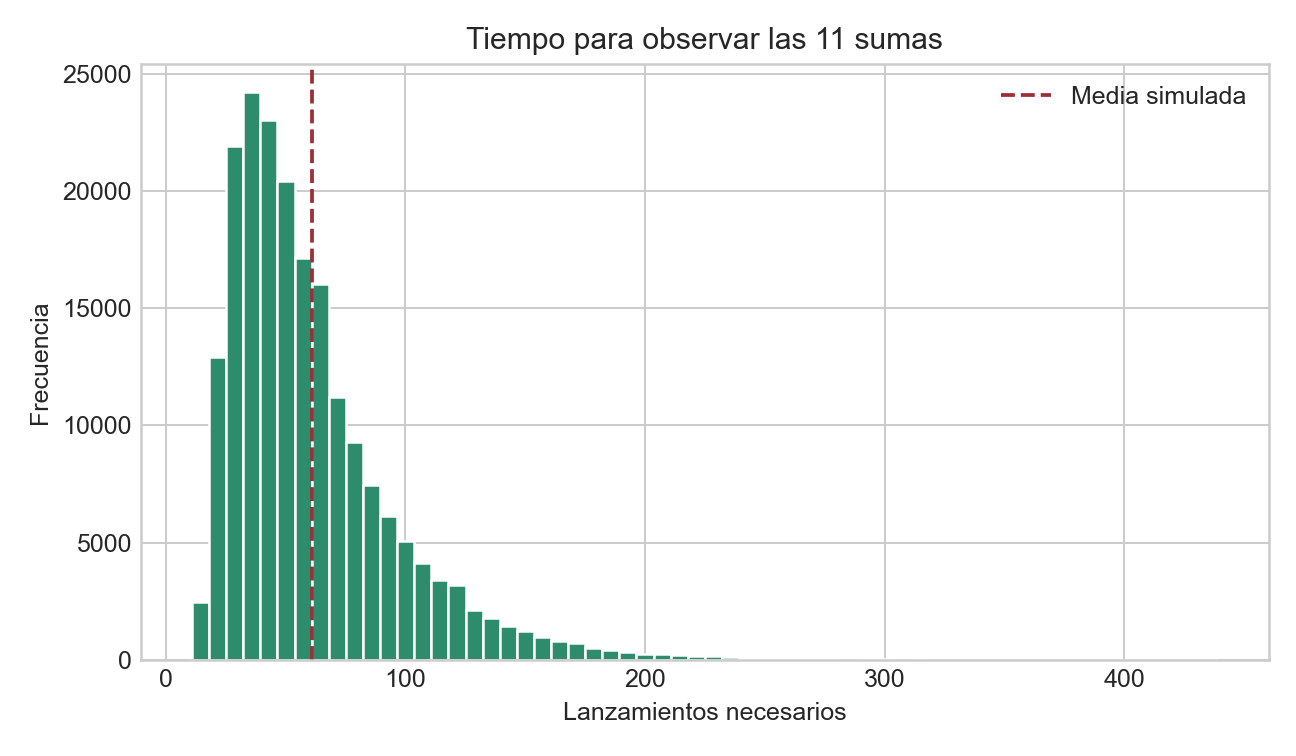

In [8]:
display(pd.Series(resumen['ejercicio_5'], name='valor').to_frame())
display(Image(filename=str(RESULTS_DIR / 'ejercicio_5_dados.png'), width=720))

## Ejercicio 6 - Suma de valores de elementos distintos

Sea `m_a` la multiplicidad del elemento distinto `a` en una lista de longitud `n`. Al elegir una posición uniforme, `P(A=a)=m_a/n`; por tanto,

`Z = n·v(A)/m_A` satisface E[Z] = sum_a v(a)`.

El promedio de muchas copias de `Z` estima la suma buscada y su error estándar cuantifica la precisión. El método requiere poder consultar o estimar `m_a`; si las multiplicidades no están disponibles, se necesita un conteo auxiliar o un esquema de muestreo distinto.

In [9]:
import numpy as np
lista = np.array(['A']*5000 + ['B']*3000 + ['C']*1500 + ['D']*500)
valores = {'A': 10, 'B': 20, 'C': 5, 'D': 40}
estimada, ee = estimar_suma_distintos(lista, valores.__getitem__, muestras=50_000)
pd.Series({'suma exacta': sum(valores.values()), 'estimación': estimada, 'error estándar': ee})

suma exacta       75.000000
estimación        75.986533
error estándar     0.758956
dtype: float64

## Ejercicio 7 - Tasas de riesgo discretas

**(a)** En el paso 2, `Y` es geométrica sobre `{1,2,...}` con parámetro `lambda`: `P(Y=k)=lambda(1-lambda)^(k-1)`.

**(b)** Las sumas parciales `S` son los tiempos candidatos de un proceso Bernoulli con probabilidad `lambda` por periodo. Un candidato en el tiempo `S` se acepta con probabilidad `lambda_S/lambda`; si se rechaza, se avanza al siguiente candidato. Es adelgazamiento (thinning) en tiempo discreto.

**(c)** Condicionado a que no hubo aceptación antes de `n`, en el periodo `n` hay candidato con probabilidad `lambda` y se acepta con probabilidad `lambda_n/lambda`. Luego `P(X=n | X>=n)=lambda_n`, que es precisamente la tasa de riesgo requerida. En consecuencia, `P(X=n)=lambda_n product_{k<n}(1-lambda_k)`.

## Ejercicio 8 - Muestreo de una distribución condicional

En un intento, la probabilidad de proponer `X=i` y aceptar es

`P(X=i) P(Y=j | X=i) = P(X=i,Y=j)`.

La probabilidad total de aceptación es la suma sobre `i`, es decir, `P(Y=j)>0`. Por lo tanto, condicionado a que el intento fue aceptado,

`P(W=i) = P(X=i,Y=j)/P(Y=j) = P(X=i | Y=j)`.

Los rechazos solo reinician intentos independientes, de modo que no alteran la distribución del primer valor aceptado.

## Ejercicio 9 - Integrales por Monte Carlo

Se usaron 500,000 muestras por integral. Para dominios infinitos se aplicaron transformaciones: `x=u/(1-u)` en la integral 6, una propuesta Cauchy en la 7 y dos exponenciales independientes en la 9. Los valores analíticos de referencia son:

3. `Ei(e)-Ei(1)`; 4. `3pi/16`; 5. `e^(-1/4)sqrt(pi)[erfi(5/2)+erfi(3/2)]/2`;
6. `1/2`; 7. `sqrt(pi)`; 8. `sqrt(pi)[erfi(2)-erfi(1)]+(2e-1-e^4)/2`; 9. `1/2`.

In [10]:
integrales = pd.read_csv(RESULTS_DIR / 'ejercicio_9_integrales.csv')
display(integrales.style.format({
    'estimación_MC': '{:.8f}', 'error_estándar': '{:.8f}',
    'IC95_inferior': '{:.8f}', 'IC95_superior': '{:.8f}',
    'valor_exacto': '{:.8f}', 'error_absoluto': '{:.8f}',
}))
print('Valores exactos dentro de sus IC 95%:',
      ((integrales.valor_exacto >= integrales.IC95_inferior) &
       (integrales.valor_exacto <= integrales.IC95_superior)).sum(), 'de', len(integrales))

,integral,estimación_MC,error_estándar,IC95_inferior,IC95_superior,valor_exacto,error_absoluto
0,3,6.31383406,0.00465946,6.30470168,6.32296644,6.31656384,0.00272978
1,4,0.58855433,0.00046921,0.58763471,0.58947396,0.58904862,0.00049429
2,5,93.25259398,0.34489256,92.57661699,93.92857097,93.16275329,0.08984069
3,6,0.49940838,0.00047537,0.49847667,0.50034010,0.50000000,0.00059162
4,7,1.77168155,0.00188704,1.76798302,1.77538008,1.77245385,0.00077230
5,8,4.90845596,0.00842756,4.89193825,4.92497367,4.89915885,0.00929711
6,9,0.50001600,0.00070711,0.49863009,0.50140191,0.50000000,0.00001600


Valores exactos dentro de sus IC 95%: 7 de 7


## Conclusión

La simulación de 15 días cumple el detalle mínimo pedido y, al contrastarla con la distribución completa, evita decidir por azar muestral. Mantener tres botellas es una política de servicio razonable: satisface 90% de la demanda por unidades y limita el faltante esperado a 0.25 botella/día. No obstante, deja 0.75 botella/día en promedio. La decisión final depende de costos: tres unidades es la elección óptima cuando el costo unitario del faltante supera al del sobrante, pero no es más de cuatro veces mayor. Si el faltante cuesta como máximo lo mismo que el sobrante conviene bajar a dos; si cuesta más de cuatro veces, conviene subir al menos a cuatro.